# One Spectral Line

*Stellar Spectroscopy from Scratch — from physical principles to a working code*

Chapter 5 gave us a smooth background of continuous absorption and
scattering. It can contain broad slopes and sharp ionization edges, but it
cannot explain a very narrow opacity excess such as the one sketched below.

<figure>
  <img src="assets/schematics/textbook/ch06-smooth-background-narrow-line-v1.png"
       alt="A smooth continuum mass-extinction ribbon with one narrow line mass-absorption bump, leading by a question arrow to two bound energy levels.">
  <figcaption><strong>Conceptual schematic: the missing narrow
  interaction.</strong> The broad ribbon is continuum mass extinction; the
  localized bump is line mass absorption. They share units of
  cm\(^{2}\) g\(^{-1}\), but scattering has not become absorption. This is
  an opacity question, not an observed flux spectrum, and the drawn heights
  are not quantitative.</figcaption>
</figure>

That leaves one concrete question:

> **What microscopic interaction adds opacity only in a narrow wavelength
> interval, and how does a working code place it on a grid?**

We will follow one isolated, ordinary Fe I transition through a controlled
six-depth LTE thermochemical state. “Fe I” means neutral iron. “LTE” means
that each layer uses its own local temperature to set excitation and the
balance between absorption and stimulated emission. “Ordinary” means that
the line follows the standard Voigt/Harris route rather than a special
hydrogen, helium, autoionizing, or partial-redistribution profile.

The chapter has three movements. First, two bound energy levels acquire an
integrated interaction strength. Second, motion and finite lifetimes
redistribute that strength into a profile. Third, the readable one-line
calculation becomes the exact CPU-atmosphere and device-synthesis products.

The supplied thermochemical state has already done the population work of
Chapters 3–4. At each depth it provides temperature \(T\), mass density
\(\rho\), electron density \(n_e\), a neutral-collision proxy, the
partition-normalized ion population \(n_{s,r}/U_{s,r}\), and the
fractional Doppler width \(\delta_l=\Delta v_D/c\). Depth index 0 is
outermost. We consume those quantities; we do not re-derive ionization,
molecules, or continuum physics here. When the line needs a local
background in Section 6.8, we call the exact Chapter 5 continuum routine
as an upstream dependency.

This chapter still computes **opacity**, not emergent intensity or flux.
Radiative transfer will come only after the complete opacity budget exists.

> **Movement I — One transition acquires strength.** Before asking how wide
> the line is, we must know which photons it can absorb and how much
> integrated opacity it carries.


In [1]:
from pathlib import Path
import sys

repository_root = Path.cwd()
if repository_root.name == "content":
    repository_root = repository_root.parent
if str(repository_root) not in sys.path:
    sys.path.insert(0, str(repository_root))
source_root = repository_root / "src"
if str(source_root) not in sys.path:
    sys.path.insert(0, str(source_root))

from book.plot_style import apply_book_plot_style

apply_book_plot_style()


In [2]:
import matplotlib.pyplot as plt
import numpy as np

from book.chapter05_runtime import load_regime_state, run_synthesis_continuum
from book.chapter06_runtime import (
    BOLTZMANN_ERG_PER_K,
    LIGHT_SPEED_NM_PER_S,
    SQRT_PI_REFERENCE,
    build_synthesis_wavelength_grid,
    collision_density_proxy,
    continuous_voigt_h,
    damping_checkpoint,
    dense_line_checkpoint,
    fast_exponential_checkpoint,
    gross_line_strength_checkpoint,
    harris_branch_checkpoint,
    profile_normalization_checkpoint,
    run_atmosphere_one_line,
    run_synthesis_one_line,
    stored_doppler_checkpoint,
    stimulated_emission_factor,
    synthesis_center_policy_checkpoint,
    synthesis_line_state,
    transition_checkpoint,
)
from book.plot_style import PAPER_COLORS, add_quiet_grid, single_panel
from payne_zero_synthesis.device import resolve_runtime

regime_names = (
    "hot_dwarf",
    "solar_dwarf",
    "low_gravity_giant",
    "cool_molecule_rich",
)
solar_state = load_regime_state("solar_dwarf", "synthesis")
fe_population = np.asarray(
    solar_state["partition_normalized_populations"][:, 0, 25],
    dtype=np.float64,
)
fe_width = np.asarray(
    solar_state["fractional_doppler_widths"][:, 0, 25],
    dtype=np.float64,
)
depth_index = 2

def finish_line_plot(axes, *, xlabel, ylabel, title, ylog=False):
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_title(title)
    if ylog:
        axes.set_yscale("log")
    add_quiet_grid(axes, axis="both" if ylog else "y")
    axes.legend()
    plt.show()
    plt.close(axes.figure)


## 6.1 Two bound levels select one photon energy

An electron in a **bound-bound transition** remains attached to the atom
before and after absorbing the photon. If its lower and upper energies are
\(E_l\) and \(E_u\), resonance requires

\[
h\nu_l=E_u-E_l,
\qquad
\lambda_l=\frac{c}{\nu_l}.
\]

Line catalogs usually store term **wavenumbers**
\(\widetilde E=E/(hc)\), in cm\(^{-1}\), rather than energies in erg.
Therefore the executable conversion is

\[
\lambda_l\,[{\rm nm}]
=\frac{10^7}
{|\widetilde E_u-\widetilde E_l|\,[{\rm cm}^{-1}]}.
\]

The factor \(10^7\) converts cm to nm. This resembles the bound-free
energy accounting in Chapter 5, except that the final electron is still
bound and only one discrete energy separation is selected.

<figure>
  <img src="assets/schematics/textbook/ch06-two-levels-one-photon-v1.png"
       alt="Lower and upper bound energy levels connected by an upward photon arrow h nu, with a wavelength marker lambda equals c over nu.">
  <figcaption><strong>Conceptual schematic: two levels, one resonant
  photon.</strong> The spacing fixes the rest wavelength. It does not yet
  determine the line strength or width; the spacing and particle counts are
  not to scale.</figcaption>
</figure>

Our checksum-bound teaching record is one raw Fe I source row. It contains
two term wavenumbers and a rounded stored wavelength. The first visible
calculation derives the wavelength from the energy separation before any
line-strength field is used.


In [3]:
transition = transition_checkpoint()
wavelength_from_levels = 1.0e7 / transition.energy_separation_cm

print(f"lower term:      {transition.lower_excitation_cm:12.3f} cm^-1")
print(f"upper term:      {transition.upper_excitation_cm:12.3f} cm^-1")
print(f"separation:      {transition.energy_separation_cm:12.3f} cm^-1")
print(f"derived lambda:  {wavelength_from_levels:16.12f} nm")
print(f"stored lambda:   {transition.stored_wavelength_nm:16.12f} nm")
print(f"stored - derived:{transition.stored_minus_derived_nm:16.8e} nm")


lower term:         33507.123 cm^-1
upper term:         53545.833 cm^-1
separation:         20038.710 cm^-1
derived lambda:  499.034119461782 nm
stored lambda:   499.034100000000 nm
stored - derived: -1.94617817e-05 nm


The live calculation gives \(499.0341194618\) nm. The stored value,
\(499.0341\) nm, differs by only about \(1.95\times10^{-5}\) nm because
it is rounded. We now know where the line is centered, but nothing here
says how many absorbers can use the transition.

## 6.2 An ion population is not a lower-level population

The supplied \(n_{s,r}/U_{s,r}\) counts an ion stage after division by
its partition function. It is not the population of this transition's
lower level. Conceptually, if the lower level has statistical weight
\(g_l\)—the number of quantum states sharing that listed energy—then

\[
n_l=\frac{n_{s,r}}{U_{s,r}}g_l
\exp\!\left(-\frac{E_l}{k_{\rm B}T}\right).
\]

The record does not provide \(g_l\) and the oscillator strength
\(f_{lu}\) separately. It provides their product

\[
(gf)_l=g_l f_{lu}.
\]

An oscillator strength is a dimensionless measure of how strongly a
transition couples to radiation. In the exact interface its field is named
`oscillator_strength`, but for an ordinary catalog record its value is
\(gf\), not bare \(f\). The executable factor is therefore

\[
\frac{n_{s,r}}{U_{s,r}}(gf)_l
\exp\!\left[-\widetilde E_l\frac{hc}{kT}\right].
\]

Because \(\widetilde E_l\) is in cm\(^{-1}\) and \(hc/kT\) is in cm,
the exponent is dimensionless. The code prints the Boltzmann factor,
the excitation-weighted normalized population, and the \(gf\)-weighted
factor separately. None is mislabeled as a directly known \(n_l\).


In [4]:
baseline_strength = gross_line_strength_checkpoint(
    partition_normalized_population_cm3=fe_population,
    mass_density_g_cm3=solar_state["mass_density"],
    fractional_doppler_width=fe_width,
    hc_over_kt_cm=solar_state["hc_over_kt"],
)

d = depth_index
exponent = (
    transition.lower_excitation_cm * solar_state["hc_over_kt"][d]
)
print(f"depth index:                           {d}")
print(f"temperature:                           {solar_state['temperature'][d]:.1f} K")
print(f"catalog gf:                            {baseline_strength.oscillator_strength:.9f}")
print(f"dimensionless excitation exponent:     {exponent:.6f}")
boltzmann = baseline_strength.lower_level_boltzmann_factor[d]
weighted = (
    baseline_strength
    .excitation_weighted_partition_normalized_population_cm3[d]
)
gf_weighted = baseline_strength.gf_weighted_excitation_factor_cm3[d]

print(f"Boltzmann factor:                       {boltzmann:.6e}")
print(f"normalized Fe I population:             {fe_population[d]:.6e} cm^-3")
print(f"excitation-weighted normalized value:   {weighted:.6e} cm^-3")
print(f"gf-weighted excitation factor:          {gf_weighted:.6e} cm^-3")


depth index:                           2
temperature:                           5200.0 K
catalog gf:                            0.138038426
dimensionless excitation exponent:     9.271014
Boltzmann factor:                       9.411302e-05
normalized Fe I population:             4.004036e+08 cm^-3
excitation-weighted normalized value:   3.768319e+04 cm^-3
gf-weighted excitation factor:          5.201728e+03 cm^-3


At this solar-like depth the normalized Fe I population is large, but the
lower level lies high enough that the Boltzmann factor is only about
\(9.4\times10^{-5}\). Excitation removes most ions from consideration
before \(gf\) sets the coupling strength. This is why “abundant ion” does
not automatically mean “strong line.”

## 6.3 The integrated strength comes before the profile

For one isolated, nonmagnetic LTE transition, the frequency-normalized
line mass absorption is

\[
\kappa_{\nu,l}=
\frac{\pi e^2}{m_ec}
\frac{n_{s,r}}{\rho U_{s,r}}(gf)_l
\exp\!\left[-\widetilde E_l\frac{hc}{kT}\right]
s_\nu(T)\,\phi_l(\nu),
\]

where \(e\) is the electron charge magnitude in CGS units, \(m_e\) is
the electron mass, \(c\) is the speed of light, and

\[
s_\nu(T)=1-\exp\!\left(-\frac{h\nu}{k_{\rm B}T}\right)
\]

subtracts stimulated emission. The profile \(\phi_l\) is, for now, only
a shape whose frequency integral is one.

At a wavelength sample \(\lambda_i\), the stored value is simply
\(\kappa_{\nu,l}(\nu=c/\lambda_i)\). It remains a mass absorption
coefficient in cm\(^{2}\) g\(^{-1}\); it is not an opacity density per
nanometre, so no \(|d\nu/d\lambda|\) factor is inserted.

Integrating over frequency removes the normalized profile. Before we
choose any shape, the result predicts linear scaling with \(gf\) and
\(n_{s,r}/U_{s,r}\), and inverse scaling with \(\rho\). The next cell
performs exactly those three perturbations.


In [5]:
doubled_gf = gross_line_strength_checkpoint(
    partition_normalized_population_cm3=fe_population,
    mass_density_g_cm3=solar_state["mass_density"],
    fractional_doppler_width=fe_width,
    hc_over_kt_cm=solar_state["hc_over_kt"],
    oscillator_strength=2.0 * transition.oscillator_strength,
)
doubled_population = gross_line_strength_checkpoint(
    partition_normalized_population_cm3=2.0 * fe_population,
    mass_density_g_cm3=solar_state["mass_density"],
    fractional_doppler_width=fe_width,
    hc_over_kt_cm=solar_state["hc_over_kt"],
)
doubled_density = gross_line_strength_checkpoint(
    partition_normalized_population_cm3=fe_population,
    mass_density_g_cm3=2.0 * solar_state["mass_density"],
    fractional_doppler_width=fe_width,
    hc_over_kt_cm=solar_state["hc_over_kt"],
)

reference = baseline_strength.integrated_strength_cm2_hz_per_g[d]
def strength_ratio(case):
    return case.integrated_strength_cm2_hz_per_g[d] / reference

print("change                         integrated-strength ratio")
print(f"gf x 2                         {strength_ratio(doubled_gf):.6f}")
print(f"normalized population x 2      {strength_ratio(doubled_population):.6f}")
print(f"mass density x 2               {strength_ratio(doubled_density):.6f}")
print(f"baseline area scale              {reference:.6e} cm^2 Hz g^-1")


change                         integrated-strength ratio
gf x 2                         2.000000
normalized population x 2      2.000000
mass density x 2               0.500000
baseline area scale              4.743921e+09 cm^2 Hz g^-1


The measured ratios are \(2\), \(2\), and \(1/2\). Those are not fitted
behaviors: they follow directly from the particle count and the
per-gram definition.

## 6.4 Stimulated emission is applied once

Stimulated emission must be applied exactly once, but the two production
lanes own that step at different times:

| lane | line accumulator returns | where \(s_\nu\) is applied |
|---|---|---|
| atmosphere | gross, pre-stimulated line opacity | later, frequency by frequency in the transfer accumulator |
| synthesis | net line opacity by default | at the end of `accumulate_atomic(..., apply_stim=True)` |

Raw slabs from the two lanes cannot be compared until this lifecycle is
aligned. We now have a trustworthy integrated strength, but it is still
concentrated at one infinitely sharp frequency.

> **Movement II — Motion and finite lifetimes create the profile.** The
amount of opacity is fixed; the next question is how it is redistributed
around \(\lambda_l\).

## 6.5 Thermal motion and microturbulence make a Gaussian core

Atoms moving toward and away from the observer Doppler-shift the resonance.
One Cartesian component of a thermal velocity distribution is Gaussian,
so the line core is Gaussian. The Doppler speed is

\[
\Delta v_D^2=\frac{2k_{\rm B}T}{m_l}+\xi^2,
\qquad
\delta_l=\frac{\Delta v_D}{c}.
\]

Here \(m_l\) is the absorber mass and \(\xi\) is **microturbulence**:
unresolved small-scale motion represented as an additional velocity
dispersion. It broadens the line but does not heat the gas, shift the
center, or create more absorbers. The supplied production state already
stores \(\delta_l\); this small experiment shows what that number means.


T=4000 K, xi=0.0: Delta v_D=1.0914 km/s, area=1.00000217
T=8000 K, xi=0.0: Delta v_D=1.5434 km/s, area=1.00000217
T=8000 K, xi=2.0: Delta v_D=2.5263 km/s, area=0.99999465


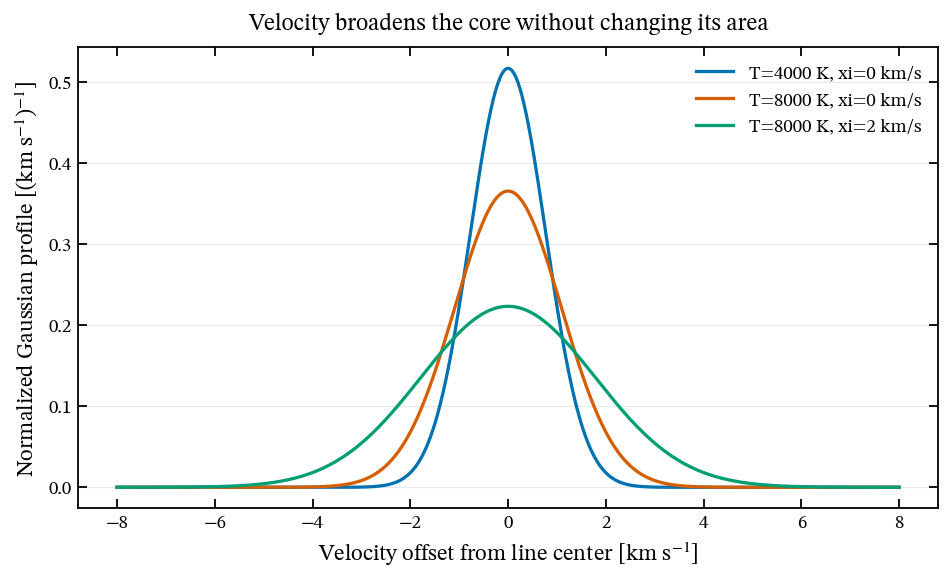

In [6]:
atomic_mass_g = 55.845 * 1.66053906660e-24
speed_km_s = np.linspace(-8.0, 8.0, 1201)
cases = ((4000.0, 0.0), (8000.0, 0.0), (8000.0, 2.0))
colours = (PAPER_COLORS["blue"], PAPER_COLORS["orange"], PAPER_COLORS["green"])

figure, axes = single_panel()
for (temperature, micro_km_s), colour in zip(cases, colours):
    thermal_cm_s = np.sqrt(2.0 * BOLTZMANN_ERG_PER_K * temperature / atomic_mass_g)
    width_km_s = np.sqrt((thermal_cm_s / 1.0e5) ** 2 + micro_km_s**2)
    profile = np.exp(-(speed_km_s / width_km_s) ** 2) / (
        SQRT_PI_REFERENCE * width_km_s
    )
    area = np.trapezoid(profile, speed_km_s)
    axes.plot(speed_km_s, profile, color=colour,
              label=f"T={temperature:.0f} K, xi={micro_km_s:.0f} km/s")
    print(f"T={temperature:4.0f} K, xi={micro_km_s:.1f}: "
          f"Delta v_D={width_km_s:.4f} km/s, area={area:.8f}")

finish_line_plot(
    axes,
    xlabel=r"Velocity offset from line center [km s$^{-1}$]",
    ylabel=r"Normalized Gaussian profile [(km s$^{-1}$)$^{-1}$]",
    title="Velocity broadens the core without changing its area",
)


Raising the temperature increases the thermal speed. Adding
\(2\ {\rm km\,s^{-1}}\) of microturbulence broadens it further. The
peak falls as the width grows, while every measured area remains
essentially one. A width redistributes an existing strength; it does not
manufacture new integrated opacity.

In production we convert the supplied fraction by

\[
\Delta\nu_D=\nu_l\delta_l,\qquad
\Delta\lambda_D\simeq\lambda_l\delta_l
\]

for a narrow line. At the representative solar depth, the stored width is
about \(2.36\ {\rm km\,s^{-1}}\), or \(3.92\times10^{-3}\) nm.

## 6.6 Finite lifetimes and perturbers make wings

A Gaussian falls extremely quickly far from line center, yet real lines
often retain extended wings. The reason is that the emitting atom does
not radiate forever.

Treat the transition classically, as an oscillator whose amplitude decays
because the state has a finite lifetime:

\[
E(t)\propto e^{-\gamma t/2}\,e^{-2\pi i\nu_l t}.
\]

A wave train of finite length is not monochromatic. Its frequency content
is the Fourier transform of \(E(t)\), and the transform of a decaying
exponential is a Lorentzian,

\[
|\tilde E(\nu)|^2\propto
\frac{1}{(\nu-\nu_l)^2+(\gamma/4\pi)^2},
\]

with full width at half maximum \(\gamma/2\pi\). Quantum mechanics gives
the same answer by a shorter route: a state that survives for
\(\Delta t\sim1/\gamma\) has an energy uncertain by
\(\Delta E\sim\hbar\gamma\), which is the same frequency width. The wings
are slow to fall off because a Lorentzian decays only as
\((\nu-\nu_l)^{-2}\), where the Gaussian decays exponentially — so far
from line center the damping branch always wins, however small
\(\gamma\) is.

Three independent processes shorten that coherent wave train and so
disturb the oscillation:

1. **radiative damping** — a finite state lifetime prevents an infinitely
   exact transition frequency;
2. **Stark damping** — charged perturbers, represented here by electrons,
   disturb the energy levels;
3. **van der Waals damping** — collisions with neutral perturbers disturb
   the levels.

The neutral proxy used by the line code is

\[
n_{\rm pert}=
(n_{\rm H\,I}+0.42n_{\rm He\,I}+0.85n_{\rm H_2})
\left(\frac{T}{10^4\ {\rm K}}\right)^{0.3}.
\]

We consume these already-computed populations. The raw radiative
coefficient is in s\(^{-1}\); the Stark and van der Waals coefficients
are in cm\(^{3}\) s\(^{-1}\), so multiplying by density first puts all
three terms on a common rate scale.

That common scale is what lets the three be added. Each process is an
independent way of terminating the same wave train, so their rates sum
to one total \(\gamma\), and a single Lorentzian of width
\(\gamma/2\pi\) describes the result — three distinct physical
mechanisms collapse into one number. Dividing by the Doppler width
expresses that width in units of the Gaussian core, which is exactly the
argument the Voigt function of §6.7 expects. The dimensionless damping
ratio is

\[
a_l=\frac{\gamma_{\rm rad}+\gamma_{\rm S}n_e+
\gamma_{\rm vdW}n_{\rm pert}}{4\pi\Delta\nu_D}.
\]

The stored record has already absorbed the required normalization into
its three damping fields, so the exact implementation adds their
density-scaled terms and divides by the fractional Doppler width.


In [7]:
neutral_proxy = collision_density_proxy(solar_state)
damping = damping_checkpoint(
    electron_density_cm3=solar_state["electron_density"],
    collision_density_proxy_cm3=neutral_proxy,
    fractional_doppler_width=fe_width,
)
more_electrons = damping_checkpoint(
    electron_density_cm3=2.0 * solar_state["electron_density"],
    collision_density_proxy_cm3=neutral_proxy,
    fractional_doppler_width=fe_width,
)
more_neutrals = damping_checkpoint(
    electron_density_cm3=solar_state["electron_density"],
    collision_density_proxy_cm3=2.0 * neutral_proxy,
    fractional_doppler_width=fe_width,
)
width = stored_doppler_checkpoint(
    temperature_k=solar_state["temperature"],
    fractional_doppler_width=fe_width,
)

print("term at depth 2                 dimensionless numerator")
print(f"radiative                       {damping.radiative_term[d]:.6e}")
print(f"electron Stark                  {damping.stark_term[d]:.6e}")
print(f"neutral van der Waals           {damping.van_der_waals_term[d]:.6e}")
print(f"damping ratio a                 {damping.damping_ratio[d]:.6e}")
print(f"Doppler width                   {width.doppler_width_km_per_s[d]:.6f} km/s")
stark_ratio = more_electrons.stark_term[d] / damping.stark_term[d]
vdw_ratio = (
    more_neutrals.van_der_waals_term[d]
    / damping.van_der_waals_term[d]
)
print(f"Stark response to ne x 2        {stark_ratio:.6f}")
print(f"vdW response to npert x 2       {vdw_ratio:.6f}")


term at depth 2                 dimensionless numerator
radiative                       3.909297e-08
electron Stark                  8.546884e-09
neutral van der Waals           4.468198e-08
damping ratio a                 1.174969e-02
Doppler width                   2.355585 km/s
Stark response to ne x 2        2.000000
vdW response to npert x 2       2.000000


The three printed contributions are separate before they are summed.
Doubling electrons changes only the Stark term; doubling neutral
perturbers changes only the van der Waals term. Their common denominator
also explains a useful coupling: a larger Doppler width makes the same
damping rate a smaller dimensionless \(a_l\).

## 6.7 The Voigt profile combines core and wings

Velocity broadening and damping are independent random processes. Their
combined frequency response is therefore a convolution: the probability
distribution of the sum of two independent shifts.

<figure>
  <img src="assets/schematics/textbook/ch06-core-wings-convolution-v1.png"
       alt="A Gaussian velocity branch and Lorentzian damping branch entering a convolution, producing a profile with a labeled core and wings.">
  <figcaption><strong>Conceptual schematic: independent causes,
  one profile.</strong> The Gaussian velocity distribution controls the
  core; the Lorentzian response preserves extended wings. Equal area refers
  to ideal continuous normalized profiles, not to a cutoff grid
  deposit.</figcaption>
</figure>

With Doppler offset

\[
u=\frac{\nu-\nu_l}{\Delta\nu_D},
\]

define the dimensionless Voigt function directly by

\[
H(a,u)=\frac{a}{\pi}
\int_{-\infty}^{\infty}
\frac{e^{-y^2}}{(u-y)^2+a^2}\,dy .
\]

The normalized frequency profile is

\[
\phi_l(\nu)=
\frac{H(a,u)}{\sqrt{\pi}\,\Delta\nu_D},
\qquad
\int_{-\infty}^{\infty}\phi_l(\nu)\,d\nu=1.
\]

The next plot evaluates the defining convolution itself. A logarithmic
ordinate makes the redistribution into the wings visible.


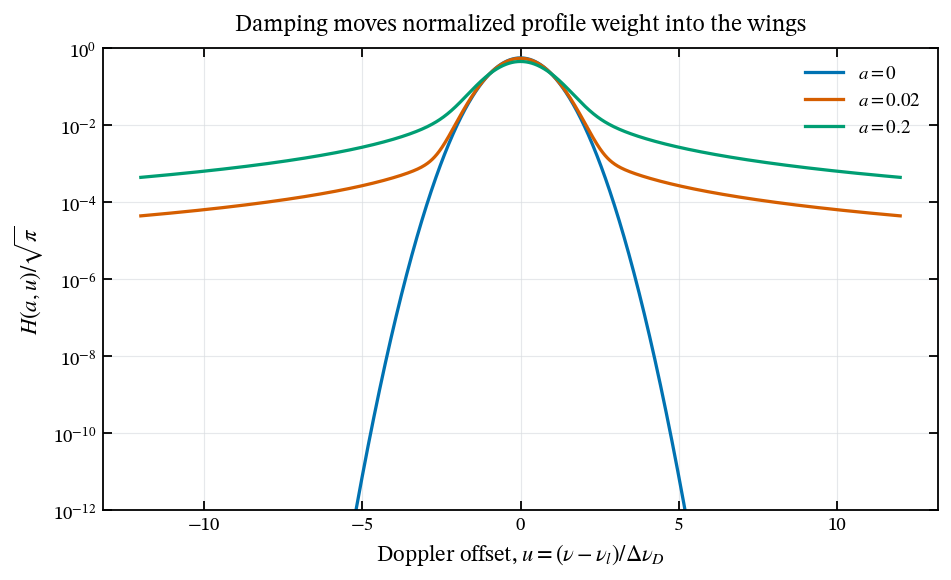

a= 0.00: wide-domain area=1.00000000, unmeasured tail fraction=-1.253e-16
a= 0.02: wide-domain area=0.99987267, unmeasured tail fraction=1.273e-04
a= 0.20: wide-domain area=0.99872670, unmeasured tail fraction=1.273e-03


In [8]:
u = np.linspace(-12.0, 12.0, 1601)
damping_cases = (0.0, 0.02, 0.2)
colours = (PAPER_COLORS["blue"], PAPER_COLORS["orange"], PAPER_COLORS["green"])
figure, axes = single_panel()
for a_value, colour in zip(damping_cases, colours):
    h_value = continuous_voigt_h(u, a_value)
    axes.plot(u, h_value / np.sqrt(np.pi), color=colour,
              label=fr"$a={a_value:g}$")

normalization = profile_normalization_checkpoint(
    np.asarray(damping_cases), integration_limit_doppler_widths=100.0
)
axes.set_ylim(1.0e-12, 1.0)
finish_line_plot(
    axes,
    xlabel=r"Doppler offset, $u=(\nu-\nu_l)/\Delta\nu_D$",
    ylabel=r"$H(a,u)/\sqrt{\pi}$",
    title="Damping moves normalized profile weight into the wings",
    ylog=True,
)
for a_value, area, missing in zip(
    normalization.damping_ratio,
    normalization.measured_integral_phi_dnu,
    normalization.relative_missing_area,
):
    print(f"a={a_value:5.2f}: wide-domain area={area:.8f}, "
          f"unmeasured tail fraction={missing:.3e}")


With \(a=0\), the profile is Gaussian. Increasing \(a\) lowers the core
and makes the far wings much larger. The wide-domain integrals remain
close to one; their small deficit is the analytically infinite tail beyond
the finite integration window. We have now separated the physical
definition from any fast approximation.

> **Movement III — One depth becomes a checked slab.** We first assemble
the transparent equation at one depth. Only afterward do tables, cutoffs,
float32 deposition, and backend ownership enter.

## 6.8 One readable line above a smooth continuum

At one depth, every factor is now known:

\[
\kappa_{\nu,l}
=A_l\,H(a_l,u)\,s_\nu(T),
\]

where \(A_l\) contains the \(gf\)-weighted normalized population, mass
density, and inverse Doppler-width scale already built above. For this
transparent checkpoint we use the continuous mathematical Voigt reference,
not the Harris table or production cutoff.


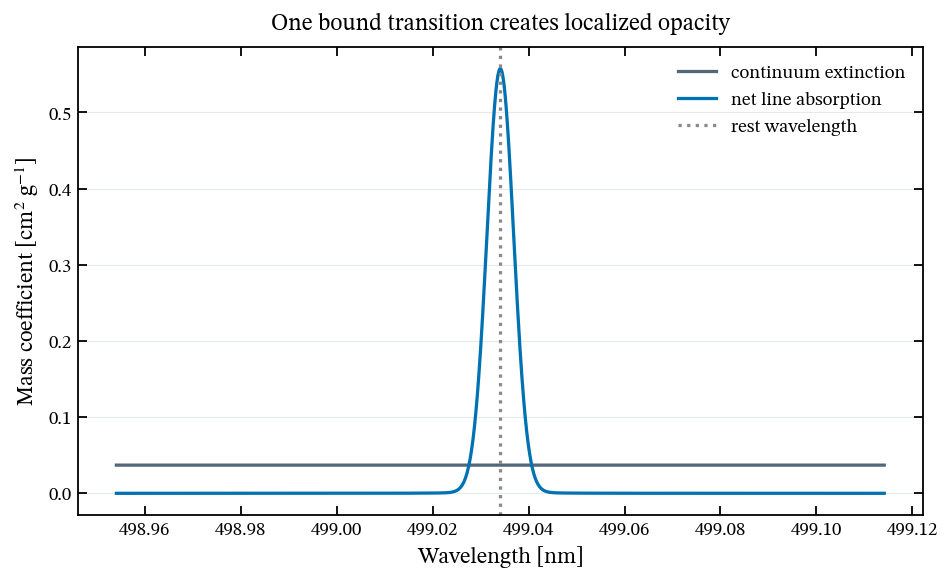

continuum at center: 3.698412e-02 cm^2 g^-1
net line at center:  5.573881e-01 cm^2 g^-1
line / continuum:    15.071


In [9]:
local_wavelength = np.linspace(
    transition.wavelength_nm - 0.08,
    transition.wavelength_nm + 0.08,
    1601,
)
readable_line = dense_line_checkpoint(
    wavelength_nm=local_wavelength,
    line_amplitude_cm2_per_g=baseline_strength.line_amplitude_cm2_per_g[d],
    fractional_doppler_width=fe_width[d],
    damping_ratio=damping.damping_ratio[d],
    temperature_k=solar_state["temperature"][d],
    depth_index=d,
    profile_lane="continuous",
)
local_continuum = run_synthesis_continuum(
    "solar_dwarf", local_wavelength
).continuum_opacity[d]

figure, axes = single_panel()
axes.plot(local_wavelength, local_continuum,
          color=PAPER_COLORS["slate"], label="continuum extinction")
axes.plot(local_wavelength,
          readable_line.net_line_mass_absorption_coefficient,
          color=PAPER_COLORS["blue"], label="net line absorption")
axes.axvline(transition.wavelength_nm, color=PAPER_COLORS["grey"],
             linestyle=":", label="rest wavelength")
finish_line_plot(
    axes,
    xlabel="Wavelength [nm]",
    ylabel=r"Mass coefficient [cm$^2$ g$^{-1}$]",
    title="One bound transition creates localized opacity",
)
center_i = int(np.argmin(np.abs(local_wavelength - transition.wavelength_nm)))
print(f"continuum at center: {local_continuum[center_i]:.6e} cm^2 g^-1")
net_center = (
    readable_line.net_line_mass_absorption_coefficient[center_i]
)
print(f"net line at center:  {net_center:.6e} cm^2 g^-1")
print(f"line / continuum:    {net_center / local_continuum[center_i]:.3f}")


At this representative depth, the line center is roughly fifteen times
the smooth continuum, yet the excess is confined to a narrow interval.
This is the physical answer to the opening schematic. It is still not a
flux dip: transfer has not decided which layers are visible.

The defining integral is too expensive to evaluate for millions of line,
depth, and wavelength combinations. We now replace pieces of the
transparent calculation one at a time and check what each replacement
changes.

## 6.9 FASTEX replaces the repeated excitation exponential

Line strength repeatedly needs \(e^{-x}\), where
\(x=\widetilde E_l hc/kT\). Both production lanes use lookup tables on a
\(0.001\)-spaced argument grid. For ordinary in-domain values, the
argument is rounded to the nearest thousandth before lookup. The
atmosphere and synthesis implementations intentionally differ at invalid
and out-of-domain inputs, so they remain separate numerical authorities.

This compact table includes one ordinary value, one half-step boundary,
and the accepted domain edge.


In [10]:
fast_arguments = np.asarray([0.2385, 0.2386, 1.0, 1000.999, 1001.0])
fast = fast_exponential_checkpoint(fast_arguments)

print("x          direct exp(-x)       atmosphere FASTEX      synthesis FASTEX")
for index, x_value in enumerate(fast.exponent_argument):
    print(
        f"{x_value:8.4f}   "
        f"{fast.exact_exp_minus_x[index]:17.9e}   "
        f"{fast.atmosphere_lookup[index]:17.9e}   "
        f"{fast.synthesis_float64_lookup[index]:17.9e}"
    )


x          direct exp(-x)       atmosphere FASTEX      synthesis FASTEX
  0.2385     7.878086883e-01     7.874148824e-01     7.874148824e-01
  0.2386     7.877299113e-01     7.874148824e-01     7.874148824e-01
  1.0000     3.678794412e-01     3.678794412e-01     3.678794412e-01
1000.9990     0.000000000e+00     0.000000000e+00     0.000000000e+00
1001.0000     0.000000000e+00     0.000000000e+00     0.000000000e+00


The ordinary values agree with the exponential at the quantized lookup
argument, not necessarily at every unrounded input. At \(x=1001\), both
production policies return zero. This is a deliberate fast approximation
with a defined domain, not a new physical law.

## 6.10 Harris tables replace the convolution

The Harris approximation expresses \(H(a,u)\) through precomputed basis
tables and branch formulas. The CPU atmosphere and Torch synthesis lanes
have separate immutable table authorities. The table below checks their
exact evaluators and also exposes the synthesis ordinary-wing shortcut:
low damping uses a compact core expression and an \(u^{-2}\) far wing,
while larger damping uses the full Harris branch.


In [11]:
harris_u = np.asarray([0.0, 1.0, 5.0, 10.5, 20.0])
harris_a = np.asarray([0.01, 0.01, 0.10, 0.01, 0.30])
harris = harris_branch_checkpoint(harris_u, harris_a)

print("u      a       atmosphere H      synthesis H       synthesis wing      branch")
for values in zip(
    harris.doppler_offset,
    harris.damping_ratio,
    harris.atmosphere_scalar_profile,
    harris.synthesis_full_profile,
    harris.synthesis_ordinary_wing_profile,
    harris.synthesis_wing_branch,
):
    u_value, a_value, atmosphere_h, synthesis_h, wing_h, branch = values
    print(f"{u_value:5.1f}  {a_value:5.2f}  {atmosphere_h:16.8e}  "
          f"{synthesis_h:16.8e}  {wing_h:16.8e}  {branch}")


u      a       atmosphere H      synthesis H       synthesis wing      branch
  0.0   0.01    9.88816200e-01    9.88816200e-01    9.88716200e-01  low-damping H0+aH1 wing
  1.0   0.01    3.68702053e-01    3.68702053e-01    3.68738841e-01  low-damping H0+aH1 wing
  5.0   0.10    2.40810001e-03    2.40810001e-03    2.40810001e-03  low-damping H0+aH1 wing
 10.5   0.01    5.11746032e-05    5.11746032e-05    5.11746032e-05  low-damping u^-2 wing
 20.0   0.30    4.24644173e-04    4.24644173e-04    4.24644173e-04  full Harris wing


These columns are close because they approximate the same Voigt physics,
but “close” is not “the same implementation.” Each lane is compared with
its own authority. The synthesis wing column additionally shows where the
ordinary-line shortcut takes ownership.

## 6.11 A production line has a cutoff and a deposition dtype

A physically normalized Voigt profile has infinite wings. A finite
computation cannot deposit every nonzero tail. The synthesis route first
asks whether the predicted center exceeds a fixed fraction of the local
continuum; it then walks outward until the wing becomes negligible under
the production policy. Accumulation is float32 on every device, even when
CPU or CUDA work arrays are float64.

The next checkpoint keeps the six solar depths separate so a line can be
active at one depth and weak at another.


In [12]:
center_policy = synthesis_center_policy_checkpoint("solar_dwarf")

print("depth  pre-cut  post-FASTEX  a          branch                 float32 center")
for depth in center_policy.depth_index:
    i = int(depth)
    print(
        f"{i:5d}  "
        f"{str(bool(center_policy.passes_pre_excitation_cutoff[i])):7s}  "
        f"{str(bool(center_policy.passes_post_fastex_cutoff[i])):11s}  "
        f"{center_policy.damping_ratio[i]:.6e}  "
        f"{str(center_policy.selected_branch[i]):21s}  "
        f"{center_policy.float32_center_deposit_cm2_per_g[i]:.7e}"
    )
center_rounding = np.max(np.abs(
    center_policy.float32_center_deposit_cm2_per_g
    - center_policy.production_center_deposit_cm2_per_g
))
print(f"maximum isolated float32 center effect: {center_rounding:.3e} cm^2 g^-1")


depth  pre-cut  post-FASTEX  a          branch                 float32 center
    0  True     True         5.224493e-03  low-damping center shortcut  1.0379502e-01
    1  True     True         5.808023e-03  low-damping center shortcut  2.3802386e-01
    2  True     True         1.174969e-02  low-damping center shortcut  5.5950832e-01
    3  True     True         6.948960e-02  low-damping center shortcut  1.9908907e+00
    4  True     True         6.331709e-01  full Harris center     4.7322717e+00
    5  True     True         8.530451e+00  full Harris center     2.5155973e+00
maximum isolated float32 center effect: 0.000e+00 cm^2 g^-1


All six solar depths survive both center gates, but their deposits differ
because population, density, width, and damping differ. The reported
float32 effect is numerical ownership at the accumulation boundary, not
physical broadening.

## 6.12 One immutable record changes through depth

The line record itself—\(\lambda_l\), \(\widetilde E_l\), \(gf\), and
damping coefficients—does not change from layer to layer. The atmosphere
changes the line amplitude, width, damping, and stimulated-emission factor.

<figure>
  <img src="assets/schematics/textbook/ch06-one-record-many-depths-v2.png"
       alt="One immutable line record enters several atmospheric layers with changing temperature, density, populations and broadening, producing a depth-by-wavelength opacity slab.">
  <figcaption><strong>Conceptual schematic: one record, many
  environments.</strong> Each row receives a different thermochemical
  state, while the atomic record stays fixed. Row colors are conceptual,
  not a parity result.</figcaption>
</figure>

Before using a sparse production deposit, we broadcast the readable Harris
line across all six supplied synthesis depths and inspect the resulting
slab.


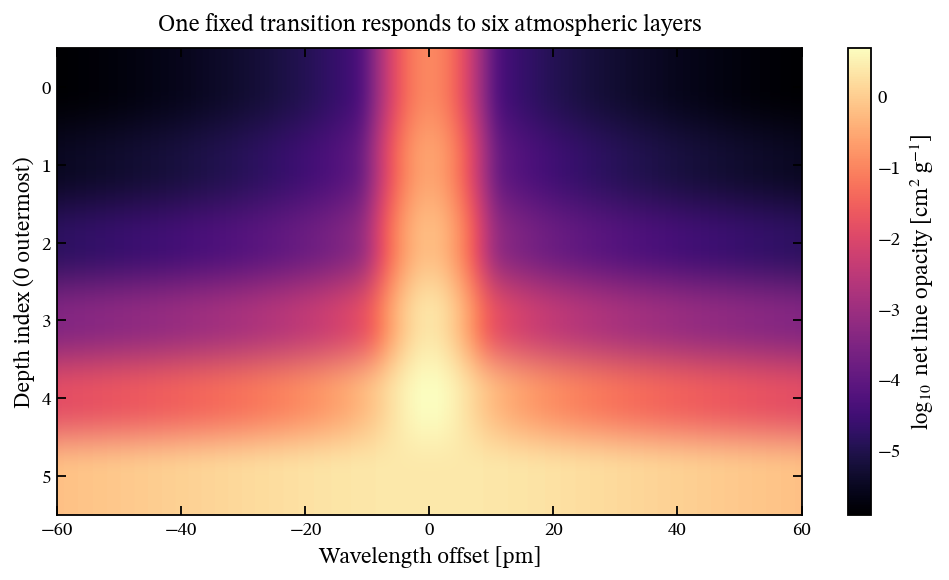

peak opacity by depth: [0.10369 0.2376  0.55739 1.98749 4.71229 2.44674]


In [13]:
slab_wavelength = np.linspace(
    transition.wavelength_nm - 0.06,
    transition.wavelength_nm + 0.06,
    1201,
)
readable_depth_slab = np.stack([
    dense_line_checkpoint(
        wavelength_nm=slab_wavelength,
        line_amplitude_cm2_per_g=baseline_strength.line_amplitude_cm2_per_g[i],
        fractional_doppler_width=fe_width[i],
        damping_ratio=damping.damping_ratio[i],
        temperature_k=solar_state["temperature"][i],
        depth_index=i,
        profile_lane="synthesis",
    ).net_line_mass_absorption_coefficient
    for i in range(fe_width.size)
])

figure, axes = single_panel()
positive = np.where(readable_depth_slab > 0.0, readable_depth_slab, np.nan)
image = axes.imshow(
    np.log10(positive),
    aspect="auto",
    origin="upper",
    extent=[
        1.0e3 * (slab_wavelength[0] - transition.wavelength_nm),
        1.0e3 * (slab_wavelength[-1] - transition.wavelength_nm),
        readable_depth_slab.shape[0] - 0.5,
        -0.5,
    ],
    cmap="magma",
)
axes.set_xlabel("Wavelength offset [pm]")
axes.set_ylabel("Depth index (0 outermost)")
axes.set_title("One fixed transition responds to six atmospheric layers")
figure.colorbar(image, ax=axes,
                label=r"$\log_{10}$ net line opacity [cm$^2$ g$^{-1}$]")
plt.show()
plt.close(figure)
print("peak opacity by depth:",
      np.array2string(np.max(readable_depth_slab, axis=1), precision=5))


The rest wavelength stays fixed, while the peak and wings change from row
to row. This is the central array shape for line opacity:
`(depth, wavelength)`. The six-depth slab is deliberately dense and
readable; production uses sparse deposition around each selected line.

## 6.13 The exact CPU-atmosphere lane

We now cross the first production boundary. The local fixture contains
only the population columns read by this selected Fe I record. The staged
source reconstructs its public dense inputs, calls the serial compiled
selected-line kernel, and returns
`line_mass_absorption_coefficient`.

The output has axes `(80, 30000)`, dtype NumPy float32, device CPU, and
units cm\(^{2}\) g\(^{-1}\). It is **gross**, pre-stimulated line
absorption. A separate float64 view applies \(s_\nu\) only to demonstrate
the later transfer ownership.


In [14]:
atmosphere_line = run_atmosphere_one_line()
atmosphere_pre = atmosphere_line.pre_stimulated_line_mass_absorption_coefficient
atmosphere_post = atmosphere_line.post_stimulated_line_mass_absorption_coefficient

support_identical = np.array_equal(atmosphere_pre != 0.0, atmosphere_post != 0.0)
print("selected records:              ", atmosphere_line.selected_line_count)
print("shape:                         ", atmosphere_pre.shape)
print("accumulation dtype / device:   ",
      atmosphere_line.accumulation_dtype, "/", atmosphere_line.device)
print("nonzero samples per depth:     ",
      np.unique(atmosphere_line.nonzero_count_per_depth).tolist())
print("peak gross opacity:            ",
      f"{atmosphere_line.peak_pre_stimulated_cm2_per_g:.9e} cm^2 g^-1")
print("gross/post support identical:  ", support_identical)
print("stimulation owner:             ", atmosphere_line.stimulation_owner)


selected records:               1
shape:                          (80, 30000)
accumulation dtype / device:    float32 / cpu
nonzero samples per depth:      [3]
peak gross opacity:             3.731258810e-01 cm^2 g^-1
gross/post support identical:   True
stimulation owner:              downstream atmosphere transfer accumulator


Exactly one record contributes. In this controlled fixture it deposits
three float32 samples per depth and reaches a peak gross opacity of about
\(0.3731\ {\rm cm^2\,g^{-1}}\). The support is unchanged when the later
stimulated-emission factor is viewed separately. This is the actual
multicore-atmosphere data contract, even though one line correctly takes
the serial compiled path: `prange` becomes useful when independent
line chunks exist, not when parallel overhead would exceed the work.

## 6.14 The exact device-synthesis lane

The synthesis path owns a different grid and a different execution model.
It precomputes invariant record tensors once, keeps star-dependent state
separate, and accumulates into Torch float32 on CPU, CUDA, or Apple Metal.
CPU and CUDA normally use float64 work arrays; Metal uses float32 because
MPS does not support float64.

We first compute the reader-built CPU result. Only then do we open the
accepted CPU comparison golden. If a default accelerator is available,
we also report its observed difference from the CPU result without
pretending that this one host establishes a universal tolerance.


In [15]:
synthesis_grid = build_synthesis_wavelength_grid()
synthesis_cpu = run_synthesis_one_line(
    "solar_dwarf",
    wavelength_nm=synthesis_grid,
    runtime_device="cpu",
)
default_device, default_work_dtype = resolve_runtime()
synthesis_default = (
    synthesis_cpu
    if default_device.type == "cpu"
    else run_synthesis_one_line(
        "solar_dwarf",
        wavelength_nm=synthesis_grid,
        runtime_device=default_device,
    )
)

synthesis_golden_path = (
    repository_root / "data/golden/payne_zero/chapter06/synthesis"
    / "chapter06_synthesis_one_line_cpu_float64_work_float32_accumulation.npz"
)
with np.load(synthesis_golden_path, allow_pickle=False) as golden:
    solar_gross_authority = np.asarray(golden["opacity__gross_float32"][1])
    solar_net_authority = np.asarray(golden["opacity__net_float32"][1])

print("CPU gross exact to authority: ",
      np.array_equal(synthesis_cpu.gross_line_mass_absorption_coefficient,
                     solar_gross_authority))
print("CPU net exact to authority:   ",
      np.array_equal(synthesis_cpu.net_line_mass_absorption_coefficient,
                     solar_net_authority))
print("shape / accumulation dtype:   ",
      synthesis_cpu.gross_line_mass_absorption_coefficient.shape,
      "/", synthesis_cpu.accumulation_dtype)
print("resolved device / work dtype: ", default_device, "/", default_work_dtype)
print("resolved-device max |gross-CPU|:",
      float(np.max(np.abs(
          synthesis_default.gross_line_mass_absorption_coefficient.astype(np.float64)
          - synthesis_cpu.gross_line_mass_absorption_coefficient.astype(np.float64)
      ))))


CPU gross exact to authority:  True
CPU net exact to authority:    True
shape / accumulation dtype:    (6, 6000) / torch.float32
resolved device / work dtype:  mps / torch.float32
resolved-device max |gross-CPU|: 1.430511474609375e-06


The reader-built CPU gross and once-stimulated net slabs are byte-exact to
their accepted authority. On this host the default device may be CPU,
CUDA, or MPS; its printed difference is an observation tied to that
backend and software stack. Structural facts—one ordinary metal record,
no special records, the same population indices, and the same sparse
support—remain exact requirements.

## 6.15 What changed at the production boundary?

The physics did not change. Its numerical representation did. The compact
ledger below keeps the two routes honest instead of forcing false
cross-lane equality.


In [16]:
route_rows = (
    ("transparent reference", "CPU NumPy float64",
     "continuous Voigt", "net in local cell", "dense local window"),
    ("atmosphere", "CPU NumPy/Numba -> float32",
     "atmosphere Harris", "later in transfer", "3 samples/depth here"),
    ("synthesis CPU", f"{synthesis_cpu.work_dtype} -> {synthesis_cpu.accumulation_dtype}",
     "Harris + ordinary shortcut", "inside accumulator", "cutoff wing walk"),
    ("synthesis default",
     f"{synthesis_default.work_dtype} -> "
     f"{synthesis_default.accumulation_dtype}",
     "same synthesis policy", "inside accumulator", "cutoff wing walk"),
)
print(f"{'route':22s} {'numeric owner':29s} {'profile':29s} {'stimulation':20s} support")
for row in route_rows:
    print(f"{row[0]:22s} {row[1]:29s} {row[2]:29s} {row[3]:20s} {row[4]}")
print("atmosphere and synthesis slab equality claimed: False")
print("reason: different grids, state depths, table authorities, and stimulation lifecycle")


route                  numeric owner                 profile                       stimulation          support
transparent reference  CPU NumPy float64             continuous Voigt              net in local cell    dense local window
atmosphere             CPU NumPy/Numba -> float32    atmosphere Harris             later in transfer    3 samples/depth here
synthesis CPU          torch.float64 -> torch.float32 Harris + ordinary shortcut    inside accumulator   cutoff wing walk
synthesis default      torch.float32 -> torch.float32 same synthesis policy         inside accumulator   cutoff wing walk
atmosphere and synthesis slab equality claimed: False
reason: different grids, state depths, table authorities, and stimulation lifecycle


The transparent calculation is the interpretive reference. FASTEX, Harris
tables, cutoffs, sparse deposits, and float32 accumulation make it fast.
The atmosphere and synthesis lanes share the ordinary-line physics but not
the same grid, depth state, table bytes, stimulation lifecycle, or parity
target.

## 6.16 The same transition in four stellar regimes

A trustworthy implementation should react to its input state. We now run
the exact CPU synthesis lane for a hot dwarf, the solar dwarf, a
low-gravity giant, and a cool molecule-rich atmosphere. The atomic record
is unchanged. Population, density, electron density, neutral perturbers,
and Doppler support change.

One compact table is more informative than four redundant plots. “Active
depths” counts rows that survive the line-center and wing policy. Peak
opacity, representative width, and representative damping describe the
resulting state; exact parity compares each reader-built CPU slab with
its corresponding accepted authority.


In [17]:
regime_results = {}
for name in regime_names:
    regime_results[name] = (
        synthesis_cpu if name == "solar_dwarf"
        else run_synthesis_one_line(
            name,
            wavelength_nm=synthesis_grid,
            runtime_device="cpu",
        )
    )

with np.load(synthesis_golden_path, allow_pickle=False) as golden:
    authority_gross = np.asarray(golden["opacity__gross_float32"])
    authority_net = np.asarray(golden["opacity__net_float32"])

print(f"{'regime':22s} {'active':>7s} {'peak gross':>13s} "
      f"{'max reach':>10s} {'exact gross/net':>17s}")
for index, name in enumerate(regime_names):
    result = regime_results[name]
    exact = (
        np.array_equal(result.gross_line_mass_absorption_coefficient,
                       authority_gross[index])
        and np.array_equal(result.net_line_mass_absorption_coefficient,
                           authority_net[index])
    )
    print(
        f"{name:22s} {np.count_nonzero(result.activity_mask):2d}/6   "
        f"{np.max(result.gross_line_mass_absorption_coefficient):13.6e} "
        f"{np.max(result.wing_reach):10d} {str(exact):>17s}"
    )


regime                  active    peak gross  max reach   exact gross/net
hot_dwarf               3/6    2.575387e-01          6              True
solar_dwarf             6/6    4.732272e+00        114              True
low_gravity_giant       6/6    2.199955e+00         32              True
cool_molecule_rich      6/6    1.785845e+00        163              True


The hot dwarf activates only three of six depths; the other three regimes
activate all six. Peak opacity and wing reach vary substantially because
the same transition encounters different atmospheric states. All four
CPU gross/net pairs reproduce their authorities exactly. This is the
behavior we want from physical code: invariant atomic data, responsive
thermochemical state, and an explicit numerical contract.

## 6.17 Chapter summary

1. A narrow line begins with two bound levels whose energy separation fixes
   the rest wavelength.
2. The record supplies \(gf\), not \(g_l\) and \(f_{lu}\) separately, so
   the executable quantity is an excitation-weighted normalized population
   followed by a \(gf\)-weighted transition factor—not an isolated
   lower-level population.
3. The \(gf\)-weighted population factor and mass density set the
   integrated opacity; stimulated emission subtracts the reverse LTE
   process exactly once.
4. Thermal motion and microturbulence create the Doppler core.
5. Radiative lifetime, electron Stark broadening, and neutral van der
   Waals collisions create Lorentzian wings through one dimensionless
   damping ratio.
6. A normalized Voigt profile expresses the physics; FASTEX, Harris
   tables, cutoffs, sparse deposits, and float32 accumulation express the
   production arithmetic.
7. The CPU atmosphere route produces its own gross, pre-stimulated NumPy
   float32 slab. The device-synthesis route produces gross and
   once-stimulated Torch float32 slabs on its own grid. Each has its own
   authority; neither output is flux, and cross-lane slab equality is not
   claimed.

### Next: From one trustworthy line to an atomic forest

One line is now trustworthy. A real wavelength window contains thousands
to millions of ordinary and special records, and the correct profile alone
does not tell us which records matter or how to add them without races.
[The next chapter builds that atomic forest.](/reader.html?ch=7)
